In [1]:
import matplotlib.pyplot as plt
from collections import Counter
import itertools

# Filtra apenas listas válidas em keywords
valid_keywords = [k for k in df_clean["keywords"] if isinstance(k, list)]
flat_keywords = list(itertools.chain.from_iterable(valid_keywords)) 
keyword_counts = Counter(flat_keywords)

# Top 15 mais comuns
most_common = keyword_counts.most_common(15)
labels, counts = zip(*most_common)

# Cria figura e eixo
fig, ax = plt.subplots(figsize=(12, 7))

# Barras horizontais (invertendo para mostrar o maior em cima)
bars = ax.barh(labels[::-1], counts[::-1], color="steelblue")

# Adiciona rótulos no fim das barras
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,                        # posição X (um pouco depois do fim)
        bar.get_y() + bar.get_height() / 2, # posição Y (meio da barra)
        f"{int(width)}",                    # valor inteiro
        va="center", ha="left", fontsize=10, fontweight="bold"
    )

# Ajustes visuais
ax.set_xlabel("Frequência")
ax.set_title("Top 15 Palavras-chave Mais Frequentes")
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


NameError: name 'df_clean' is not defined

In [ ]:
#1
import os
import pickle
import pandas as pd
from dataclasses import asdict

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan
import re
import unicodedata

In [ ]:
#2
def extract_researches_results(rot_dir: str | os.PathLike): 
    researches = []
    for papers in os.listdir(rot_dir):
        researches_results_path = os.path.join(rot_dir, papers)
        with open(researches_results_path, "rb") as file: 
            research = asdict(pickle.load(file))
            researches.append(research)
    return researches

def extract_papers(researches : list[dict]):            
    papers = []
    for results in researches:
        for paper in results["papers"].values():
            papers.append(paper)
    return papers

/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


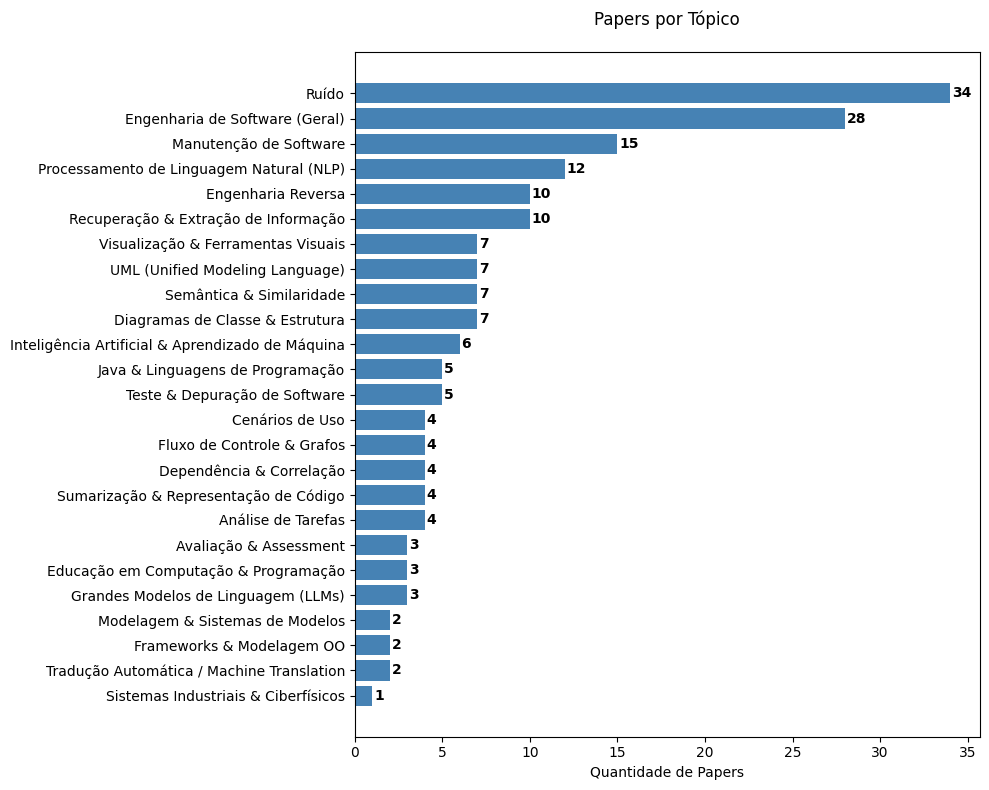

In [ ]:
#5
import pandas as pd
import matplotlib.pyplot as plt
cluster_names = {
    -1:  "Ruído",
    0:   "Dependência & Correlação",
    1:   "Cenários de Uso",
    2:   "Fluxo de Controle & Grafos",
    3:   "Diagramas de Classe & Estrutura",
    4:   "Avaliação & Assessment",
    5:   "Recuperação & Extração de Informação",
    6:   "Análise de Tarefas",
    7:   "Teste & Depuração de Software",
    8:   "Tradução Automática / Machine Translation",
    9:   "Sistemas Industriais & Ciberfísicos",
    10:  "Frameworks & Modelagem OO",
    11:  "Semântica & Similaridade",
    12:  "Engenharia Reversa",
    13:  "Visualização & Ferramentas Visuais",
    14:  "Inteligência Artificial & Aprendizado de Máquina",
    15:  "Manutenção de Software",
    16:  "Processamento de Linguagem Natural (NLP)",
    17:  "Grandes Modelos de Linguagem (LLMs)",
    18:  "Modelagem & Sistemas de Modelos",
    19:  "UML (Unified Modeling Language)",
    20:  "Engenharia de Software (Geral)",
    21:  "Educação em Computação & Programação",
    22:  "Sumarização & Representação de Código",
    23:  "Java & Linguagens de Programação"
}

tp = df_clean.explode("topic_ids", ignore_index=True)

tp = tp[tp["topic_ids"] != "Other"]

topic_counts = (
    tp.groupby("topic_ids")
      .size()
      .rename("n")
      .reset_index()
)

topic_counts["topic_name"] = topic_counts["topic_ids"].map(cluster_names)

topic_counts = topic_counts.sort_values("n", ascending=True)

plt.figure(figsize=(10, 8))
ax = plt.gca()

bars = ax.barh(topic_counts["topic_name"], topic_counts["n"], color="steelblue")

plt.title("Papers por Tópico", pad=20)
plt.xlabel("Quantidade de Papers")

# Adiciona rótulos no fim das barras
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,                        # posição X (um pouco depois do fim)
        bar.get_y() + bar.get_height() / 2, # posição Y (meio da barra)
        f"{width:.0f}",                     # texto (sem casas decimais)
        va="center", ha="left", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.show()



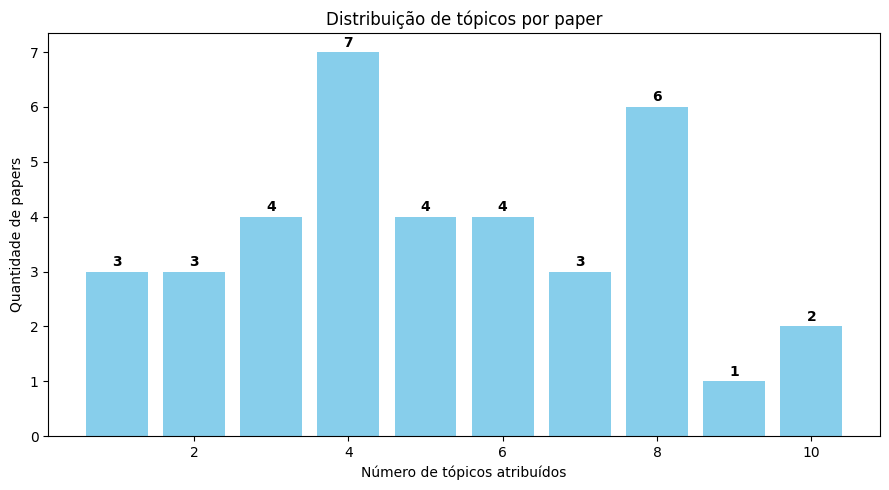

In [98]:
import matplotlib.pyplot as plt

# Conta quantos tópicos cada paper tem
df_clean["num_topics"] = df_clean["topic_ids"].apply(len)

# Distribuição
topic_dist = df_clean["num_topics"].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(9,5))
plt.bar(topic_dist.index, topic_dist.values, color="skyblue")

plt.title("Distribuição de tópicos por paper")
plt.xlabel("Número de tópicos atribuídos")
plt.ylabel("Quantidade de papers")

# rótulos em cima das barras
for i, v in enumerate(topic_dist.values):
    plt.text(topic_dist.index[i], v + 0.1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()



In [99]:
from itertools import combinations

# cria dicionário {paper_index: set(topics)}
paper_topics = {
    i: set(t for t in topics if t != "Other")
    for i, topics in enumerate(df_clean["topic_ids"])
}

# calcula interseções par a par
pairs = []
for (i, ti), (j, tj) in combinations(paper_topics.items(), 2):
    common = ti & tj
    if common:  # só guarda se tiver algo em comum
        pairs.append(((i, j), len(common), list(common)))

# ordena pelos que têm mais tópicos em comum
pairs_sorted = sorted(pairs, key=lambda x: -x[1])
for pair, n, common in pairs_sorted[:10]:
    print(f"Papers {pair} têm {n} tópicos em comum: {common}")


Papers (15, 33) têm 6 tópicos em comum: [4, 5, 11, 16, 22, -1]
Papers (20, 28) têm 6 tópicos em comum: [3, 12, 19, 20, 23, -1]
Papers (21, 26) têm 6 tópicos em comum: [2, 12, 15, 20, 23, -1]
Papers (22, 26) têm 6 tópicos em comum: [7, 13, 15, 20, 23, -1]
Papers (26, 28) têm 6 tópicos em comum: [3, 12, 13, 20, 23, -1]
Papers (5, 6) têm 5 tópicos em comum: [5, 14, 16, 20, -1]
Papers (5, 15) têm 5 tópicos em comum: [5, 8, 11, 16, -1]
Papers (5, 18) têm 5 tópicos em comum: [5, 11, 16, 20, -1]
Papers (5, 19) têm 5 tópicos em comum: [5, 13, 14, 16, -1]
Papers (6, 19) têm 5 tópicos em comum: [5, 14, 15, 16, -1]


In [100]:
import pandas as pd

# lista de tópicos únicos (exceto "Other")
all_topics = sorted({t for ids in df_clean["topic_ids"] for t in ids if t != "Other"})

# constrói matriz binária
paper_matrix = pd.DataFrame(0, index=df_clean.index, columns=all_topics)
for i, topics in enumerate(df_clean["topic_ids"]):
    for t in topics:
        if t != "Other":
            paper_matrix.loc[i, t] = 1

paper_matrix.head()


,-1,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1,1,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


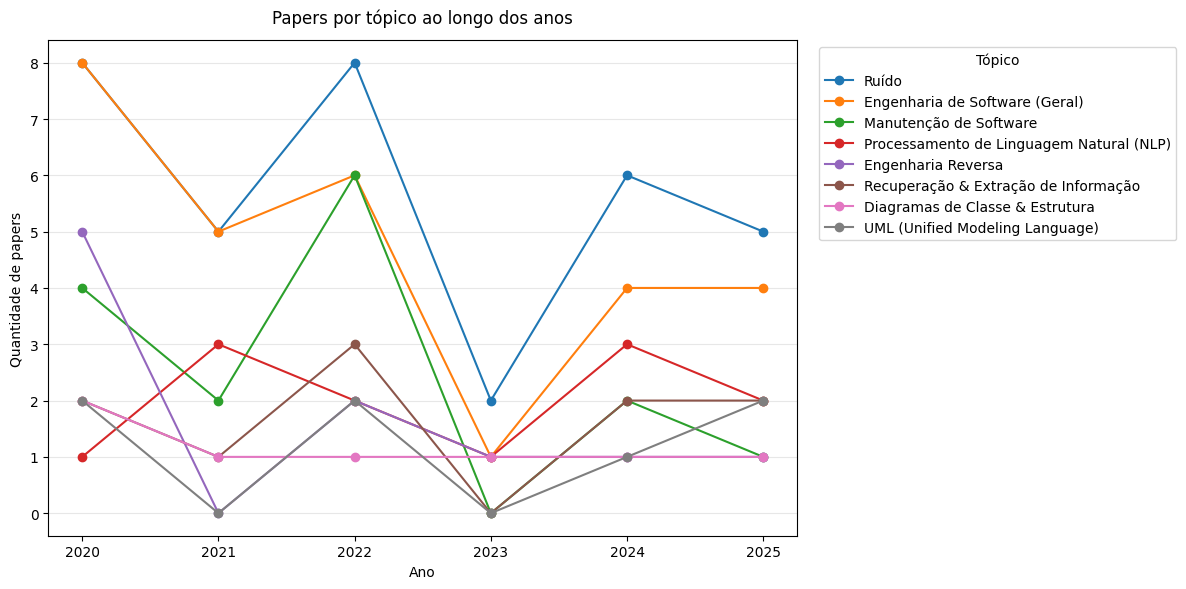

In [103]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) garante que existe uma coluna 'year' (caso ainda não tenha)
def parse_year(s):
    if pd.isna(s): 
        return None
    if isinstance(s, (int, float)): 
        return int(s)
    m = re.search(r"(19|20)\d{2}", str(s))
    return int(m.group(0)) if m else None

if "year" not in df_clean.columns:
    df_clean["year"] = df_clean["date"].apply(parse_year) if "date" in df_clean.columns else None

# --- 1) explode (paper, tópico)
tp = df_clean.explode("topic_ids", ignore_index=True)

# remove rotulo "Other" se existir
tp = tp[tp["topic_ids"] != "Other"]

# mapeia ids -> nomes amigáveis
tp["topic_name"] = tp["topic_ids"].map(cluster_names)

# remove anos nulos e ordena
tp = tp[tp["year"].notna()].copy()
tp["year"] = tp["year"].astype(int)

# --- 2) contagem por (ano, tópico) e pivot para wide
counts = (tp.groupby(["year", "topic_name"])
            .size()
            .rename("n")
            .reset_index()
            .pivot(index="year", columns="topic_name", values="n")
            .fillna(0)
            .sort_index())

# --- 3) (opcional) escolher apenas os TOP_K tópicos mais frequentes no período
TOP_K = 8  # ajuste como preferir; use None para todos
if TOP_K is not None:
    top_topics = counts.sum(axis=0).sort_values(ascending=False).head(TOP_K).index
    counts = counts[top_topics]

# --- 4) plot: múltiplas linhas (uma por tópico)
plt.figure(figsize=(12,6))
ax = counts.plot(ax=plt.gca(), marker="o")  # uma linha por coluna (tópico)

ax.set_title("Papers por tópico ao longo dos anos", pad=12)
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de papers")
ax.grid(True, axis="y", alpha=0.3)

# legenda fora do gráfico para não poluir
ax.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [101]:
from sklearn.cluster import KMeans

# define número de clusters (ajuste conforme dataset)
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean["paper_cluster"] = kmeans.fit_predict(paper_matrix)

# ver resultado
print(df_clean[["title", "topic_ids", "paper_cluster"]].head())


                                                                                        title  \
0  Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project   
1         Test2Feature: feature-based test traceability tool for highly configurable software   
2                                                    Executable Multi-Layered Software Models   
3                          Re-Engineering Microservices into Web-Based Software Product Lines   
4                           Enhancing Model-Driven Reverse Engineering Using Machine Learning   

          topic_ids  paper_cluster  
0   [-1, 5, 15, 20]              4  
1   [-1, 7, 15, 20]              4  
2  [-1, 10, 19, 20]              3  
3      [-1, 19, 20]              0  
4           [Other]              0  


In [67]:
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(df_clean)

                                                                                                                                               title  \
0                                                         Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project   
1                                                                Test2Feature: feature-based test traceability tool for highly configurable software   
2                                                                                                           Executable Multi-Layered Software Models   
3                                                                                 Re-Engineering Microservices into Web-Based Software Product Lines   
4                                                                                  Enhancing Model-Driven Reverse Engineering Using Machine Learning   
5                                                                       An Empirical Stu

In [68]:
for cluster_id, keywords in clusters.items():
    print(f"\nCluster {cluster_id}:")
    for kw in keywords:
        print(f"  - {kw}")


Cluster -1:
  - Human-centered computing
  - Information systems
  - Social and professional topics
  - Professional topics
  - Management of computing and information systems
  - Software creation and management
  - Software post-development issues
  - Software notations and tools
  - Reusability
  - Software product lines
  - Software verification and validation
  - Process validation
  - Traceability
  - Software defect analysis
  - System description languages
  - Applied computing
  - Arts and humanities
  - Computing methodologies
  - Software evolution
  - Software version control
  - Security and privacy
  - Systems security
  - Operating systems security
  - Trusted computing
  - Context specific languages
  - Domain specific languages
  - Education
  - Human computer interaction (HCI)
  - Computing education programs
  - Computer science education
  - Software organization and properties
  - Graph Neural Networks
  - Training Set
  - Gated Recurrent Unit
  - Long Short-term 

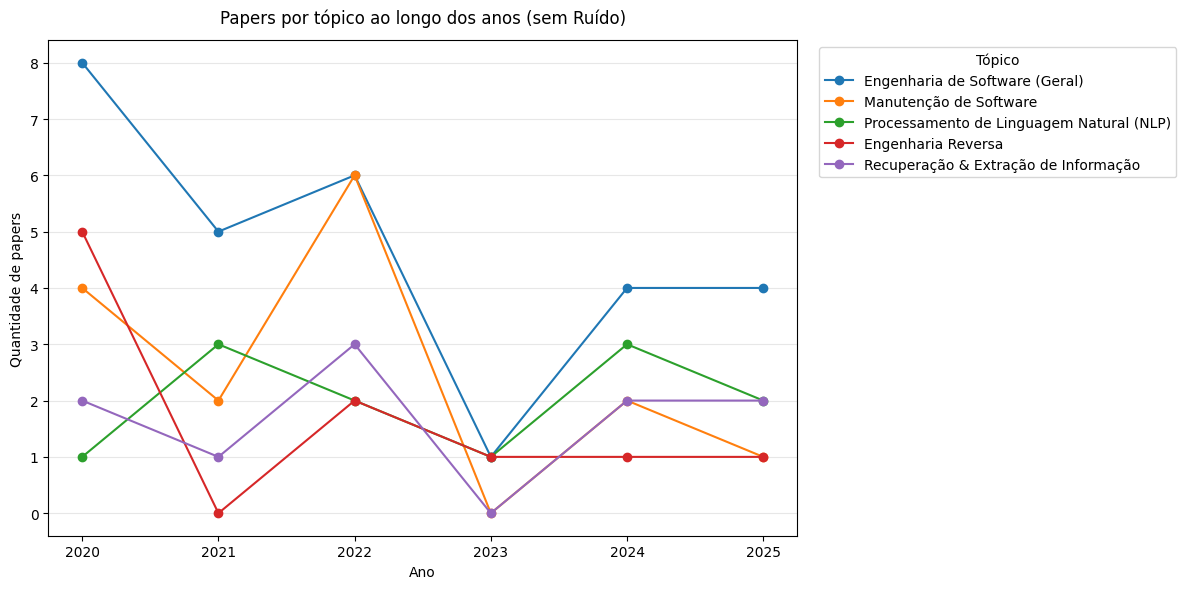

In [115]:
# explode (paper, tópico)
tp = df_clean.explode("topic_ids", ignore_index=True)

# remove rótulos inválidos
tp = tp[(tp["topic_ids"] != "Other") & (tp["topic_ids"] != -1)]

# mapeia ids -> nomes amigáveis
tp["topic_name"] = tp["topic_ids"].map(cluster_names)

# remove anos nulos e ordena
tp = tp[tp["year"].notna()].copy()
tp["year"] = tp["year"].astype(int)

# contagem por (ano, tópico)
counts = (tp.groupby(["year", "topic_name"])
            .size()
            .rename("n")
            .reset_index()
            .pivot(index="year", columns="topic_name", values="n")
            .fillna(0)
            .sort_index())

# opcional: limitar aos mais frequentes
TOP_K = 5
if TOP_K is not None:
    top_topics = counts.sum(axis=0).sort_values(ascending=False).head(TOP_K).index
    counts = counts[top_topics]

# plot
plt.figure(figsize=(12,6))
ax = counts.plot(ax=plt.gca(), marker="o")

ax.set_title("Papers por tópico ao longo dos anos (sem Ruído)", pad=12)
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de papers")
ax.grid(True, axis="y", alpha=0.3)

ax.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [1]:
import itertools
import pandas as pd

# 1a) tópicos por paper (sem "Other" e sem ruído -1)
topic_sets = (df_clean["topic_ids"]
                .apply(lambda xs: sorted({t for t in xs if t != "Other" and t != -1})))

# 1b) lista de tópicos únicos e mapeamento id->nome
all_topics = sorted({t for ts in topic_sets for t in ts})
topic_to_name = {t: cluster_names.get(t, f"Cluster {t}") for t in all_topics}

# 1c) contar coocorrência (peso = quantos papers contêm o par)
pairs = []
for ts in topic_sets:
    for a, b in itertools.combinations(ts, 2):
        pairs.append(tuple(sorted((a, b))))

edges_df = (pd.DataFrame(pairs, columns=["a","b"])
              .value_counts()
              .rename("weight_count")   # contagem bruta (nº papers em comum)
              .reset_index()
              .sort_values("weight_count", ascending=False))

# 1d) também guarda suporte individual p/ normalizações
topic_support = (pd.Series([t for ts in topic_sets for t in ts])
                   .value_counts()
                   .rename("support"))  # nº de papers que têm o tópico t

# 1e) peso normalizado (Jaccard entre conjuntos de papers)
# J(a,b) = interseção / união = count(a,b) / (count(a)+count(b)-count(a,b))
edges_df["weight_jaccard"] = edges_df.apply(
    lambda r: r["weight_count"] / (topic_support[r["a"]] + topic_support[r["b"]] - r["weight_count"]),
    axis=1
)


NameError: name 'df_clean' is not defined

In [117]:
import networkx as nx

# escolha a métrica de peso: "weight_count" ou "weight_jaccard"
WEIGHT_COL = "weight_count"    # troque para "weight_jaccard" se preferir normalizado
THRESHOLD  = 2                 # exibe só pares com pelo menos 2 papers em comum (ajuste)

# cria grafo
G = nx.Graph()
# adiciona nós primeiro (com atributos úteis)
for t in all_topics:
    G.add_node(t,
               label=topic_to_name[t],
               support=int(topic_support[t]))

# adiciona arestas com peso
for _, row in edges_df.iterrows():
    if row[WEIGHT_COL] >= THRESHOLD:
        G.add_edge(row["a"], row["b"], weight=float(row[WEIGHT_COL]))

print(G.number_of_nodes(), "nós;", G.number_of_edges(), "arestas (após filtro)")


24 nós; 88 arestas (após filtro)


In [118]:
from networkx.algorithms.community import greedy_modularity_communities

if G.number_of_edges() == 0:
    H = G.copy()  # pode estar muito filtrado; relaxe THRESHOLD se necessário
else:
    H = G.copy()

communities = list(greedy_modularity_communities(H))
comm_map = {}
for cid, comm in enumerate(communities):
    for t in comm:
        comm_map[t] = cid

nx.set_node_attributes(H, comm_map, "community")


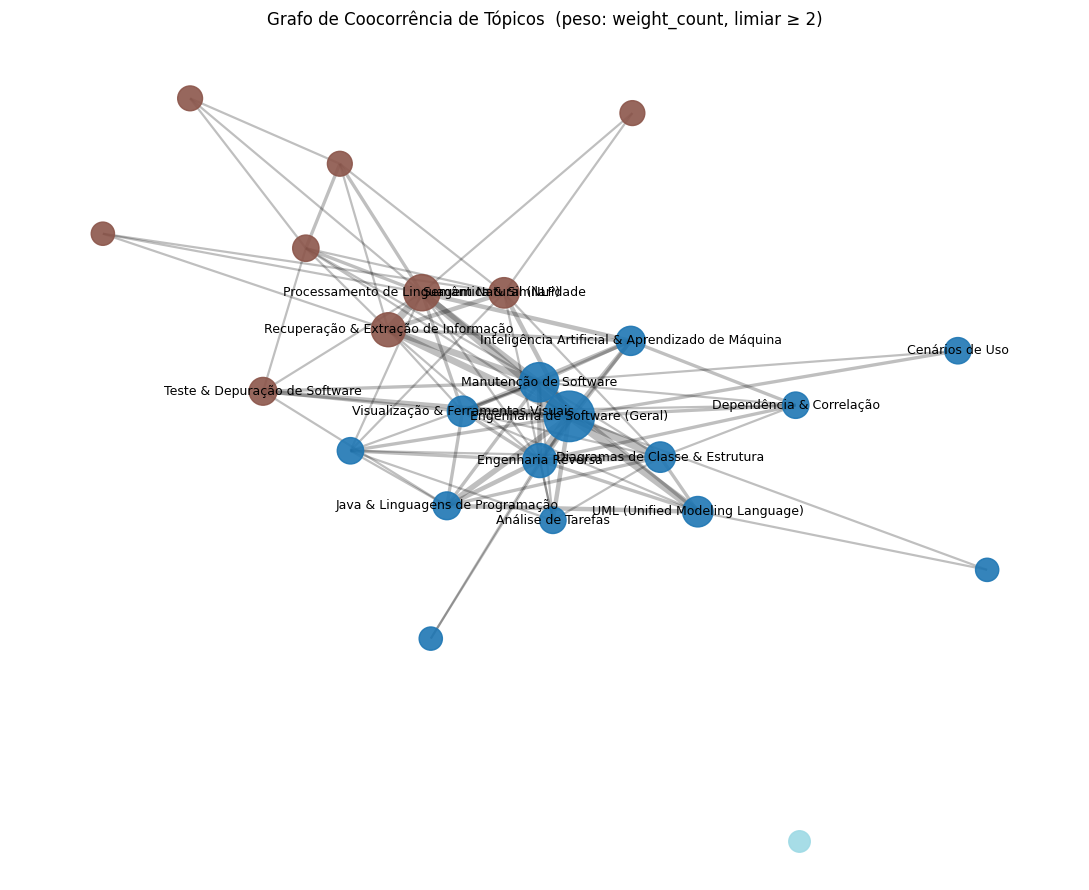

In [119]:
import matplotlib.pyplot as plt

# posição (spring), tamanho do nó ~ suporte, cor ~ comunidade
pos = nx.spring_layout(H, seed=42, k=0.8)
node_sizes = [200 + 40*topic_support[n] for n in H.nodes()]
node_colors = [comm_map.get(n, -1) for n in H.nodes()]

plt.figure(figsize=(11, 9))
nx.draw_networkx_edges(H, pos, alpha=0.25, width=[0.8*H[u][v]["weight"] for u,v in H.edges()])

nodes = nx.draw_networkx_nodes(
    H, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="tab20",
    alpha=0.9
)

# rotular só os top-N por suporte para não poluir
TOP_LABELS = 15
top_nodes = topic_support.sort_values(ascending=False).head(TOP_LABELS).index
labels = {n: topic_to_name[n] for n in H.nodes() if n in top_nodes}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=9)

plt.title(f"Grafo de Coocorrência de Tópicos  (peso: {WEIGHT_COL}, limiar ≥ {THRESHOLD})")
plt.axis("off")
plt.tight_layout()
plt.show()


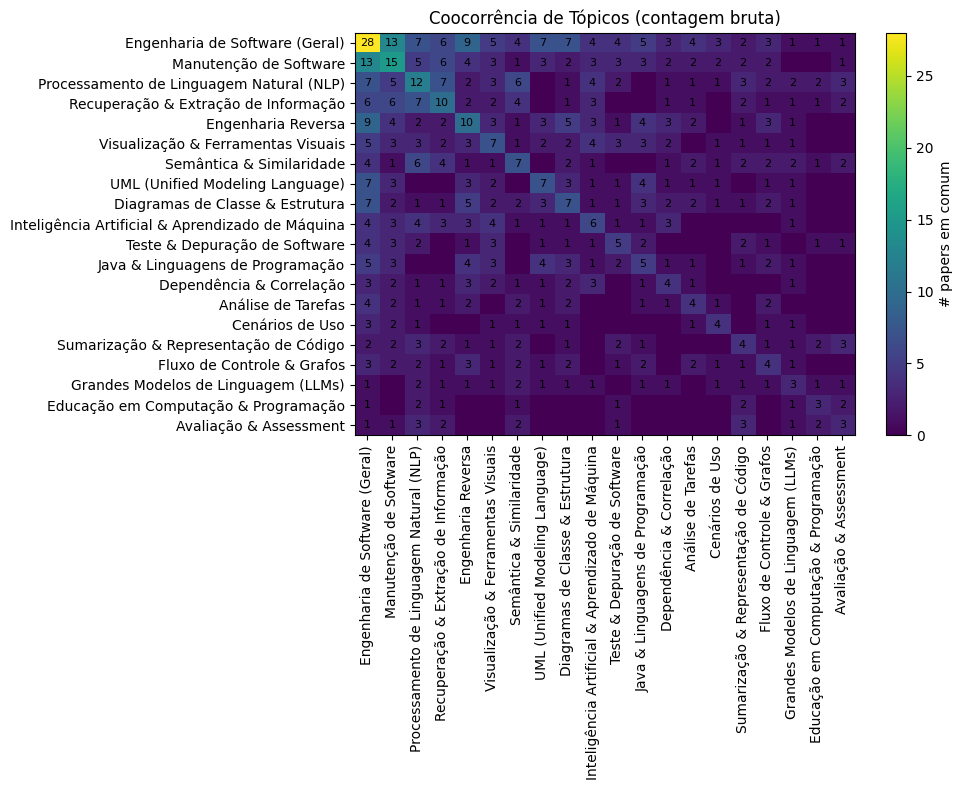

In [122]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- 1) preparar topic_sets sem "Other" e -1
topic_sets = (df_clean["topic_ids"]
                .apply(lambda xs: sorted({t for t in xs if t != "Other" and t != -1})))

# tópicos ordenados por frequência (suporte)
topic_support = (pd.Series([t for ts in topic_sets for t in ts])
                   .value_counts()
                   .rename("support"))

# escolha top-K (ou use None para todos)
TOP_K = 20
topics = topic_support.head(TOP_K).index.tolist() if TOP_K else topic_support.index.tolist()

# -------- 2) matriz de coocorrência (contagem)
idx = {t:i for i,t in enumerate(topics)}
cooc = np.zeros((len(topics), len(topics)), dtype=int)

for ts in topic_sets:
    # restrito aos tópicos escolhidos
    ts = [t for t in ts if t in idx]
    # diagonal (presença do tópico no paper)
    for t in ts:
        cooc[idx[t], idx[t]] += 1
    # pares
    for a, b in itertools.combinations(ts, 2):
        i, j = idx[a], idx[b]
        cooc[i, j] += 1
        cooc[j, i] += 1

# -------- 3) plot do heatmap
labels = [cluster_names.get(t, f"Cluster {t}") for t in topics]

plt.figure(figsize=(10, 8))
im = plt.imshow(cooc, aspect="auto")
plt.colorbar(im, label="# papers em comum")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Coocorrência de Tópicos (contagem bruta)")

for i in range(len(labels)):
    for j in range(len(labels)):
        val = cooc[i, j]  # ou jacc[i, j] para o normalizado
        if val > 0:
            plt.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8)


plt.tight_layout()
plt.show()


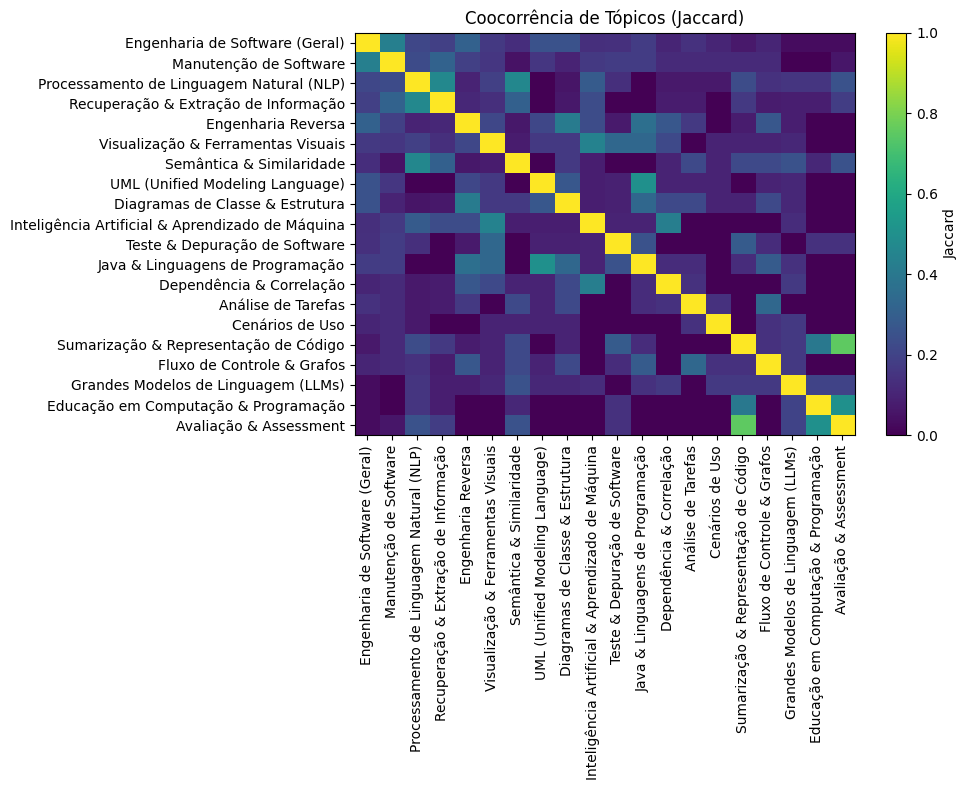

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# suporte individual de cada tópico (já calculado acima: topic_support)
support = topic_support.reindex(topics).to_numpy()

# matriz Jaccard: J(i,j) = intersec / (sup_i + sup_j - intersec)
intersec = cooc.copy().astype(float)        # usa a matriz de contagem feita acima
sup_i = support.reshape(-1, 1)
sup_j = support.reshape(1, -1)
union = sup_i + sup_j - intersec
with np.errstate(divide='ignore', invalid='ignore'):
    jacc = np.where(union > 0, intersec / union, 0.0)

plt.figure(figsize=(10, 8))
im = plt.imshow(jacc, vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, label="Jaccard")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Coocorrência de Tópicos (Jaccard)")
plt.tight_layout()
plt.show()


In [124]:
import pandas as pd

# explode a coluna keywords (cada linha vira paper–keyword único)
tp_kw = df_clean.explode("keywords", ignore_index=True)

# filtrar só keywords válidas
tp_kw = tp_kw[tp_kw["keywords"].notna() & tp_kw["keywords"].astype(str).str.strip().ne("")]

# cria matriz binária paper × keyword
paper_kw = pd.crosstab(tp_kw.index, tp_kw["keywords"]).astype(int)

# paper_kw agora é (n_papers × n_keywords) com 0/1


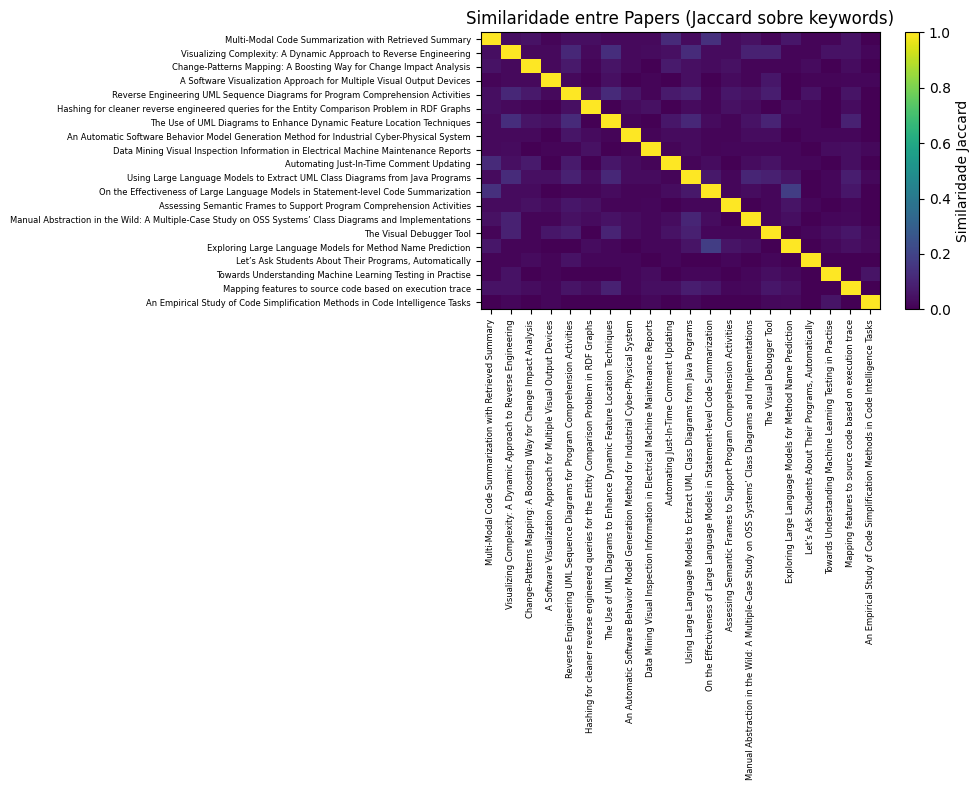

In [129]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# 1) Matriz binária paper × keyword (índice alinhado com df_clean)
tp_kw = df_clean[["keywords"]].explode("keywords")
tp_kw = tp_kw[tp_kw["keywords"].notna() & tp_kw["keywords"].astype(str).str.strip().ne("")]

paper_kw = pd.crosstab(tp_kw.index, tp_kw["keywords"]).astype("uint8")  # linhas = papers (índice de df_clean)

# 2) Remova papers sem nenhuma keyword
mask = paper_kw.sum(axis=1) > 0
paper_kw = paper_kw.loc[mask]

# labels para exibir (use um id/DOI/título — aqui vou usar o título se existir)
labels = (df_clean.loc[paper_kw.index, "title"]
          if "title" in df_clean.columns
          else paper_kw.index.astype(str))

# 3) Arrays para as métricas
X_bool  = paper_kw.to_numpy(dtype=bool)   # para Jaccard
X_float = paper_kw.to_numpy(dtype=float)  # para Cosine

# 4) Similaridade Jaccard (1 - distância de Jaccard)
D_jacc   = pairwise_distances(X_bool, metric="jaccard")
S_jacc   = 1.0 - D_jacc
jacc_df  = pd.DataFrame(S_jacc, index=labels, columns=labels)

# 5) Similaridade Cosseno (aceita float/sparse)
S_cos    = cosine_similarity(X_float)
cos_df   = pd.DataFrame(S_cos, index=labels, columns=labels)

# 6) Heatmap (Jaccard). Se tiver muitos papers, escolha um subconjunto (ex.: top 40 por nº de keywords)
MAXP = 20
if len(jacc_df) > MAXP:
    # exemplo de critério: mais “densos” (mais keywords)
    top_idx = paper_kw.sum(axis=1).sort_values(ascending=False).head(MAXP).index
    jacc_plot = jacc_df.loc[labels.loc[top_idx], labels.loc[top_idx]]
else:
    jacc_plot = jacc_df

plt.figure(figsize=(10, 8))
im = plt.imshow(jacc_plot.values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, label="Similaridade Jaccard")
plt.xticks(range(len(jacc_plot)), jacc_plot.columns, rotation=90, fontsize=6)
plt.yticks(range(len(jacc_plot)), jacc_plot.index, fontsize=6)
plt.title("Similaridade entre Papers (Jaccard sobre keywords)")
plt.tight_layout()
plt.show()


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) garantir um id estável por paper
df_clean = df_clean.reset_index(drop=True).copy()
df_clean["_pid"] = df_clean.index  # id numérico

# 2) (opcional, mas recomendado) normalizar e deduplicar keywords por paper
def clean_kw_list(lst):
    if not isinstance(lst, (list, tuple, set)):
        return []
    out = []
    for k in lst:
        if isinstance(k, str):
            k2 = k.strip()
            if k2:
                out.append(k2)
    # set() remove duplicadas do mesmo paper
    return sorted(set(out))

df_clean["kw_set"] = df_clean["keywords"].apply(clean_kw_list)

# 3) explodir para (paper, keyword) e tirar duplicadas por segurança
tp_kw = df_clean[["_pid", "kw_set"]].explode("kw_set", ignore_index=True)
tp_kw = tp_kw[tp_kw["kw_set"].notna() & tp_kw["kw_set"].astype(str).str.len().gt(0)]
tp_kw = tp_kw.drop_duplicates(subset=["_pid", "kw_set"])

# 4) matriz binária papers × keywords
paper_kw = pd.crosstab(tp_kw["_pid"], tp_kw["kw_set"]).astype("uint8")

# 5) produto matricial
M = paper_kw.to_numpy(dtype=np.uint16)
common = M @ M.T

# 6) labels alinhados exatamente com as linhas de paper_kw
row_labels = df_clean.loc[paper_kw.index, "title"].fillna(
    df_clean.loc[paper_kw.index, "DOI"].astype(str)
)

common_df = pd.DataFrame(common, index=row_labels, columns=row_labels)


# opcional: ver os 5×5 primeiros
#display(common_df.iloc[:5, :5])
display(common_df)


title,Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project,Test2Feature: feature-based test traceability tool for highly configurable software,Executable Multi-Layered Software Models,Re-Engineering Microservices into Web-Based Software Product Lines,An Empirical Study of Code Simplification Methods in Code Intelligence Tasks,Automated Framework to Extract Software Requirements from Source Code,A Survey on Renamings of Software Entities,Automating just-in-time comment updating,VarSem: declarative expression and automated inference of variable usage semantics,Attention Distribution Graph: Visualizing Student’s Attention Transition in Error-finding Tasks,...,An Automatic Software Behavior Model Generation Method for Industrial Cyber-Physical System,Using Large Language Models to Extract UML Class Diagrams from Java Programs,Manual Abstraction in the Wild: A Multiple-Case Study on OSS Systems’ Class Diagrams and Implementations,Mapping features to source code based on execution trace,The Use of UML Diagrams to Enhance Dynamic Feature Location Techniques,Assessing Semantic Frames to Support Program Comprehension Activities,On the Effectiveness of Large Language Models in Statement-level Code Summarization,Towards Understanding Machine Learning Testing in Practise,Exploring Large Language Models for Method Name Prediction,Message from NLBSE 2025 Program Chairs
title,,,,,,,,,,,,,,,,,,,,,
Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project,12,3,3,3,2,4,3,4,2,3,...,0,0,0,0,1,0,0,0,0,0
Test2Feature: feature-based test traceability tool for highly configurable software,3,12,3,6,1,4,2,4,2,0,...,0,0,0,0,0,0,0,0,0,0
Executable Multi-Layered Software Models,3,3,9,5,1,3,2,3,2,0,...,0,1,0,0,0,0,0,0,0,0
Re-Engineering Microservices into Web-Based Software Product Lines,3,6,5,8,1,3,2,3,2,0,...,0,1,0,0,0,0,0,0,0,0
An Empirical Study of Code Simplification Methods in Code Intelligence Tasks,2,1,1,1,14,5,1,1,1,2,...,0,1,0,0,0,0,0,2,1,0
Automated Framework to Extract Software Requirements from Source Code,4,4,3,3,5,11,3,6,2,0,...,0,0,0,0,0,0,0,0,1,0
A Survey on Renamings of Software Entities,3,2,2,2,1,3,4,3,1,0,...,0,0,0,0,0,0,0,0,0,0
Automating just-in-time comment updating,4,4,3,3,1,6,3,7,2,0,...,0,0,0,0,0,0,0,0,0,0
VarSem: declarative expression and automated inference of variable usage semantics,2,2,2,2,1,2,1,2,8,0,...,0,0,0,0,0,0,0,0,0,0


In [135]:
import numpy as np
import pandas as pd

# 1) Média global (entre todos os pares i<j, exclui diagonal)
A = common_df.to_numpy()
n = A.shape[0]
if n > 1:
    mean_global = A[np.triu_indices(n, k=1)].mean()
    median_global = np.median(A[np.triu_indices(n, k=1)])
else:
    mean_global = float("nan"); median_global = float("nan")

print(f"Média global de keywords em comum (pares i≠j): {mean_global:.3f}")
print(f"Mediana global (pares i≠j): {median_global:.3f}")

# 2) Média por paper (média das interseções desse paper com todos os outros)
diag = np.diag(A)
per_paper_mean = (common_df.sum(axis=1) - diag) / (n - 1 if n > 1 else 1)
per_paper_mean.name = "mean_common_keywords"
display(per_paper_mean.sort_values(ascending=False).to_frame().head(10))

# 3) (Opcional) Média por grupo/cluster de papers, se você tiver df_clean["paper_cluster"]
if "paper_cluster" in df_clean.columns:
    # alinhar índices
    aligned = per_paper_mean.reindex(common_df.index)
    tmp = pd.DataFrame({
        "paper": common_df.index,
        "cluster": df_clean.loc[df_clean["title"].isin(common_df.index), "paper_cluster"].values,
        "mean_common_keywords": aligned.values
    })
    display(tmp.groupby("cluster")["mean_common_keywords"].mean().sort_values(ascending=False))


Média global de keywords em comum (pares i≠j): 1.045
Mediana global (pares i≠j): 0.000


,mean_common_keywords
title,
Visualizing Complexity: A Dynamic Approach to Reverse Engineering,2.235294
Reverse Engineering UML Sequence Diagrams for Program Comprehension Activities,2.029412
Using Large Language Models to Extract UML Class Diagrams from Java Programs,2.029412
The Use of UML Diagrams to Enhance Dynamic Feature Location Techniques,1.852941
Multi-Modal Code Summarization with Retrieved Summary,1.647059
The Visual Debugger Tool,1.470588
Supporting Readability by Comprehending the Hierarchical Abstraction of a Software Project,1.441176
On the Effectiveness of Large Language Models in Statement-level Code Summarization,1.294118
Automating Just-In-Time Comment Updating,1.294118


cluster
2    1.352941
1    1.147059
3    1.082353
4    1.022624
0    0.568627
Name: mean_common_keywords, dtype: float64